# Edit-Distance Graph Analysis: GILGFVFTL-specific TCRs

Builds Hamming and Levenshtein edit-distance graphs from GILGFVFTL-specific
TRB CDR3 sequences pulled from the `isalgo/airr_benchmark` Hugging Face dataset
(latest bundled `vdjdb.slim.txt.gz`, filtered to human HLA-A*02 entries). Finds
the largest connected component, verifies the conserved **RS** motif, and draws
the subgraph with hub nodes highlighted.

In [1]:
import importlib.metadata as _meta
import sys as _sys
print(f"Python {_sys.version.split()[0]}")
for _pkg in ["mirpy-lib", "numpy", "pandas", "matplotlib", "scipy", "polars"]:
    try:
        print(f"  {_pkg}: {_meta.version(_pkg)}")
    except _meta.PackageNotFoundError:
        pass

import sys
import time
from pathlib import Path

import igraph as ig
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

repo_root = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from mir.common.clonotype import Clonotype
from mir.graph.edit_distance_graph import build_edit_distance_graph
from mir.utils.notebook_assets import ensure_airr_benchmark, find_airr_benchmark_vdjdb_slim

# Publication-quality matplotlib style (Nature/Science aesthetics)
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "axes.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.major.size": 3.5,
    "ytick.major.size": 3.5,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "axes.grid": False,
})


Python 3.12.12
  mirpy-lib: 1.0.0
  numpy: 2.4.4
  pandas: 2.3.3
  matplotlib: 3.10.9
  scipy: 1.17.1
  polars: 1.39.3


/Users/mikesh/vcs/mirpy/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load data

The notebook downloads `airr_benchmark` on first use, locates the latest bundled
`vdjdb.slim.txt.gz`, and filters to human TRB rearrangements for the
`GILGFVFTL` epitope with `HLA-A*02` in `mhc.a`. Because the working list carries
no consistent V-gene annotation across entries, we assign the placeholder
`"TRB"` so the `v_gene_match` parameter can still be exercised.

In [2]:
benchmark_root = ensure_airr_benchmark(repo_root, allow_patterns=["vdjdb/**"])
vdjdb_path = find_airr_benchmark_vdjdb_slim(benchmark_root)
vdjdb = pd.read_csv(vdjdb_path, sep="\t")

mask = vdjdb["gene"].eq("TRB") & vdjdb["antigen.epitope"].eq("GILGFVFTL")
if "species" in vdjdb.columns:
    mask &= vdjdb["species"].eq("HomoSapiens")
if "mhc.a" in vdjdb.columns:
    mask &= vdjdb["mhc.a"].fillna("").str.contains("A*02", regex=False)

cdr3s = sorted(vdjdb.loc[mask, "cdr3"].dropna().astype(str).unique())
rearrangements = [
    Clonotype(sequence_id=str(i), locus="TRB", v_gene="TRB", j_gene="TRBJ2-1", junction_aa=seq, duplicate_count=1, _validate=False)
    for i, seq in enumerate(cdr3s)
]

print(f"Loaded {len(rearrangements)} CDR3 sequences from {vdjdb_path}")
print(f"Length distribution: {sorted(set(len(s) for s in cdr3s))}")
print(f"Sequences with RS motif: {sum(1 for s in cdr3s if 'RS' in s)}")

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Fetching 3 files: 100%|██████████| 3/3 [00:00<00:00, 1692.16it/s]

Loaded 5236 CDR3 sequences from /Users/mikesh/vcs/mirpy/notebooks/assets/large/airr_benchmark/vdjdb/vdjdb-2025-12-29/vdjdb.slim.txt.gz
Length distribution: [6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 33, 38]
Sequences with RS motif: 680


## 2. Hamming graph (threshold = 1)

In [3]:
t0 = time.perf_counter()
g_hamming = build_edit_distance_graph(
    rearrangements,
    metric="hamming",
    threshold=1,
    n_jobs=1,   # use n_jobs > 1 for larger datasets
)
print(f"Hamming graph built in {time.perf_counter()-t0:.2f}s")
print(f"  Vertices : {g_hamming.vcount()}")
print(f"  Edges    : {g_hamming.ecount()}")

comps = g_hamming.components()
print(f"  Components: {len(comps)}")
cc_sizes = sorted(comps.sizes(), reverse=True)
print(f"  Top-5 component sizes: {cc_sizes[:5]}")

Hamming graph built in 0.07s
  Vertices : 5236
  Edges    : 4727
  Components: 3550
  Top-5 component sizes: [896, 129, 129, 116, 18]


### 2a. Largest connected component

In [4]:
largest_ham = comps.giant()
seqs_ham = largest_ham.vs["name"]

print(f"Largest CC: {largest_ham.vcount()} vertices, {largest_ham.ecount()} edges")
print("\nSample sequences from largest CC:")
for s in sorted(seqs_ham)[:10]:
    print(f"  {s}")

Largest CC: 896 vertices, 2985 edges

Sample sequences from largest CC:
  CAASSRSTDTQYF
  CAASTRSTDTQYF
  CACSGRSGETQYF
  CACSIRSTDTQYF
  CAGSIRSSYEQYF
  CAGSIRSTETQYF
  CAGSSRSGHEQYF
  CAGSTRSSYEQYF
  CANSFRSGETQYF
  CANSIRSSYEQYF


### 2b. Verify RS motif

In [5]:
rs_in_cc = [s for s in seqs_ham if "RS" in s]
print(f"RS-motif sequences in largest CC: {len(rs_in_cc)}")
print("Examples:")
for s in rs_in_cc[:8]:
    print(f"  {s}")

assert len(rs_in_cc) > 0, "Largest CC must contain RS-motif sequences"

RS-motif sequences in largest CC: 455
Examples:
  CAASSRSTDTQYF
  CAASTRSTDTQYF
  CACSGRSGETQYF
  CACSIRSTDTQYF
  CAGSIRSSYEQYF
  CAGSIRSTETQYF
  CAGSSRSGHEQYF
  CAGSTRSSYEQYF


## 3. Hamming graph with v_gene_match = True

Because all rearrangements share the placeholder `"TRB"` V-gene, the filter
leaves the graph unchanged.  In real data with annotated V-genes this would
restrict edges to within-V-gene pairs.

In [6]:
g_hamming_vmatch = build_edit_distance_graph(
    rearrangements,
    metric="hamming",
    threshold=1,
    v_gene_match=True,
    n_jobs=1,
)
print(f"Hamming (v_gene_match=True): {g_hamming_vmatch.ecount()} edges  "
      f"(plain: {g_hamming.ecount()})")

Hamming (v_gene_match=True): 4727 edges  (plain: 4727)


## 4. Levenshtein graph (threshold = 1)

In [7]:
t0 = time.perf_counter()
g_lev = build_edit_distance_graph(
    rearrangements,
    metric="levenshtein",
    threshold=1,
    n_jobs=1,
)
print(f"Levenshtein graph built in {time.perf_counter()-t0:.2f}s")
print(f"  Vertices : {g_lev.vcount()}")
print(f"  Edges    : {g_lev.ecount()}  (≥ Hamming: {g_lev.ecount() >= g_hamming.ecount()})")

largest_lev = g_lev.components().giant()
seqs_lev = largest_lev.vs["name"]
print(f"\nLargest CC (Levenshtein): {largest_lev.vcount()} vertices")
rs_lev = [s for s in seqs_lev if "RS" in s]
print(f"RS-motif sequences: {len(rs_lev)}")

Levenshtein graph built in 0.11s
  Vertices : 5236
  Edges    : 4951  (≥ Hamming: True)

Largest CC (Levenshtein): 1195 vertices
RS-motif sequences: 473


### Levenshtein with v_gene_match

In [8]:
g_lev_vmatch = build_edit_distance_graph(
    rearrangements,
    metric="levenshtein",
    threshold=1,
    v_gene_match=True,
    n_jobs=1,
)
print(f"Levenshtein (v_gene_match=True): {g_lev_vmatch.ecount()} edges  "
      f"(plain: {g_lev.ecount()})")

Levenshtein (v_gene_match=True): 4951 edges  (plain: 4951)


## 5. Visualise the largest Hamming CC

Hub nodes (top 7 by degree) are drawn in red and labelled with their
`junction_aa` and V-gene placeholder.

In [9]:
subg = largest_ham
degrees = subg.degree()

N_HUBS = 7
top_idx = sorted(range(subg.vcount()), key=lambda i: degrees[i], reverse=True)[:N_HUBS]
hub_set = set(top_idx)

print(f"Hub nodes (top {N_HUBS} by degree):")
for i in top_idx:
    v = subg.vs[i]
    print(f"  {v['name']}  v_gene={v['v_gene']}  degree={degrees[i]}")

Hub nodes (top 7 by degree):
  CASSIRSSYEQYF  v_gene=TRB  degree=52
  CASSIRSTDTQYF  v_gene=TRB  degree=42
  CASSTRSTDTQYF  v_gene=TRB  degree=31
  CASSIRSAYEQYF  v_gene=TRB  degree=30
  CASSIRSGYEQYF  v_gene=TRB  degree=29
  CASSIRSTGELFF  v_gene=TRB  degree=28
  CASSGRSTDTQYF  v_gene=TRB  degree=24


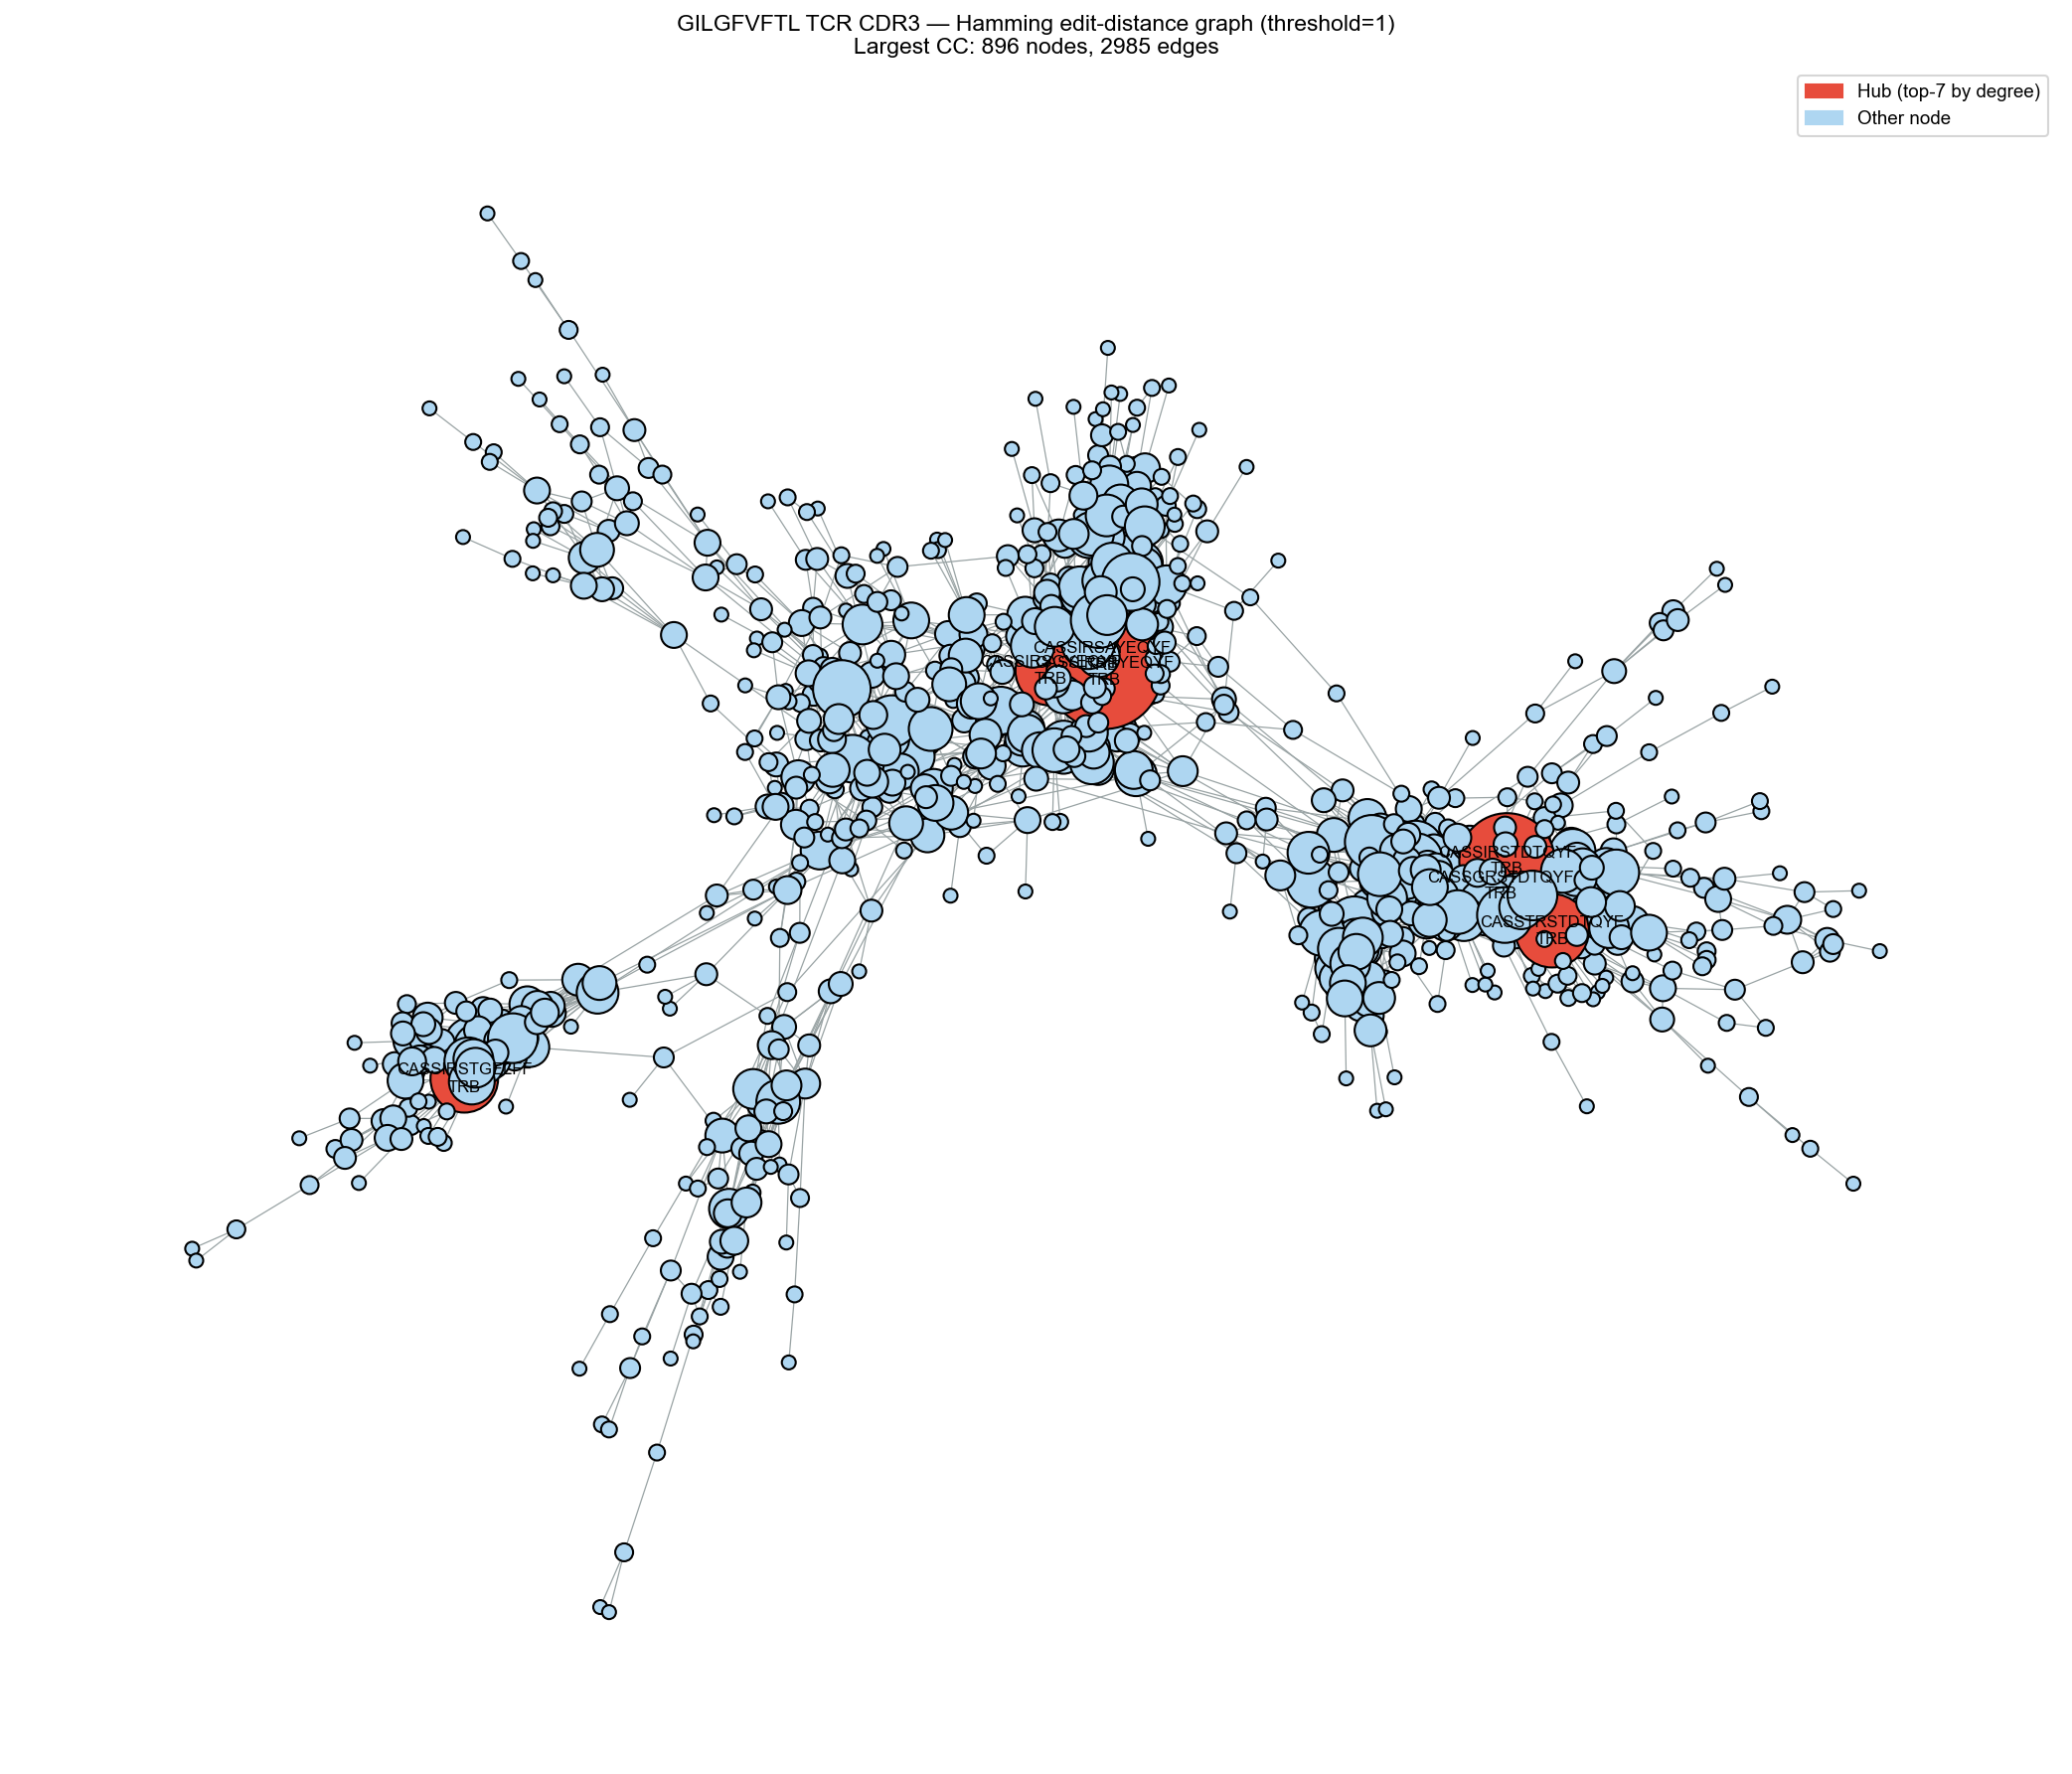

In [10]:
layout = subg.layout("fr")

vertex_colors = ["#e74c3c" if i in hub_set else "#aed6f1" for i in range(subg.vcount())]
vertex_sizes  = [12 + degrees[i] * 2 for i in range(subg.vcount())]
vertex_labels = [
    f"{subg.vs[i]['name']}\n{subg.vs[i]['v_gene']}" if i in hub_set else ""
    for i in range(subg.vcount())
]

fig, ax = plt.subplots(figsize=(14, 12))
ig.plot(
    subg,
    target=ax,
    layout=layout,
    vertex_color=vertex_colors,
    vertex_size=vertex_sizes,
    vertex_label=vertex_labels,
    vertex_label_size=8,
    vertex_label_color="black",
    edge_width=0.6,
    edge_color="#99a3a4",
)

hub_patch = mpatches.Patch(color="#e74c3c", label=f"Hub (top-{N_HUBS} by degree)")
node_patch = mpatches.Patch(color="#aed6f1", label="Other node")
ax.legend(handles=[hub_patch, node_patch], loc="upper right", fontsize=9)

ax.set_title(
    f"GILGFVFTL TCR CDR3 — Hamming edit-distance graph (threshold=1)\n"
    f"Largest CC: {subg.vcount()} nodes, {subg.ecount()} edges",
    fontsize=11,
)
ax.axis("off")
plt.tight_layout()
plt.show()